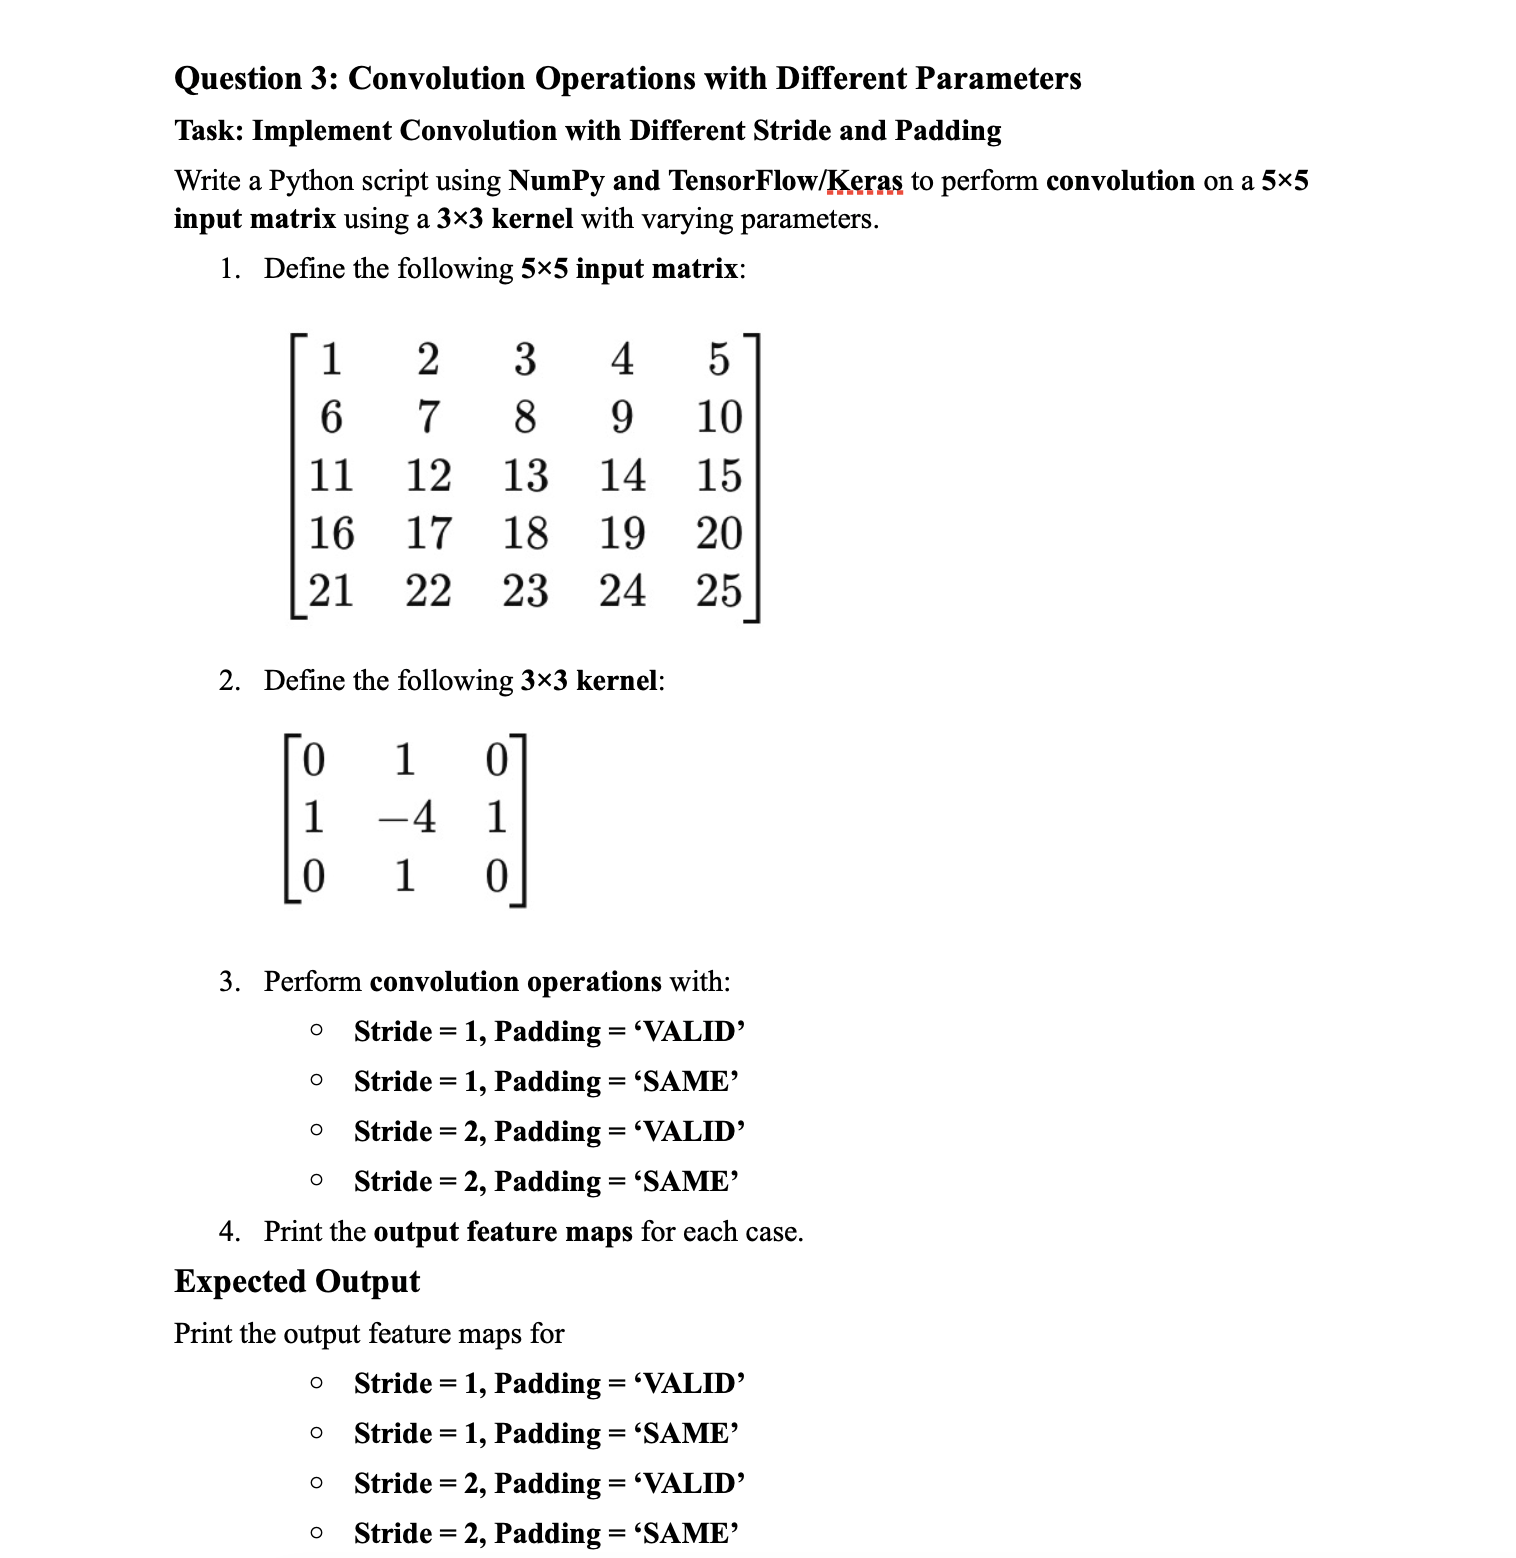

In [1]:
import numpy as np
import tensorflow as tf

In [2]:


input_matrix = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)


kernel = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)


print("Input Matrix:")
print(input_matrix)

print("\nKernel:")
print(kernel)

Input Matrix:
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

Kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


In [3]:
# prepare the data for tensorflow

input_tensor = input_matrix.reshape(1, 5, 5, 1)
kernel_tensor = kernel.reshape(3, 3, 1, 1)


print("Input Tensor Shape:", input_tensor.shape)
print("Kernel Tensor Shape:", kernel_tensor.shape)

Input Tensor Shape: (1, 5, 5, 1)
Kernel Tensor Shape: (3, 3, 1, 1)


In [4]:
# convolution function 
def run_convolution(stride, padding):
    
    conv_layer = tf.keras.layers.Conv2D(
        filters=1,
        kernel_size=(3, 3),
        strides=(stride, stride),
        padding=padding,
        use_bias=False
    )
    
    
    conv_layer.build((1, 5, 5, 1))
    conv_layer.set_weights([kernel_tensor])
    
 
    output_tensor = conv_layer(input_tensor)
    
   
    output_matrix = np.squeeze(output_tensor.numpy())
    
    print(f"\n--- Stride = {stride}, Padding = '{padding}' ---")
    print(output_matrix)

In [5]:
run_convolution(stride=1, padding='VALID')
run_convolution(stride=1, padding='SAME')
run_convolution(stride=2, padding='VALID')
run_convolution(stride=2, padding='SAME')


--- Stride = 1, Padding = 'VALID' ---
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

--- Stride = 1, Padding = 'SAME' ---
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

--- Stride = 2, Padding = 'VALID' ---
[[0. 0.]
 [0. 0.]]

--- Stride = 2, Padding = 'SAME' ---
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]
